In [1]:
import nrrd as nrrd
import pydicom as dicom
import nibabel as nib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import tqdm
import os
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [2]:
PatientID_list=['2','4','9','10','15','17','19','20','25','29','32','34','36','39','48']
test_PatientID_list=['52','56','57','65']

### Load feature vectors for projection/direct PHT results

In [6]:
### Read feature vectors
project5longest_3dslicer=np.load('../feature_vectors/project5longest_3dslicer.npy')
project5longest_medpseg=np.load('../feature_vectors/project5longest_medpseg.npy')
projectLR_3dslicer=np.load('../feature_vectors/projectLR_3dslicer.npy')
projectLR_medpseg=np.load('../feature_vectors/projectLR_medpseg.npy')
direct5longest_3dslicer=np.load('../feature_vectors/direct5longest_3dslicer.npy')
direct5longest_medpseg=np.load('../feature_vectors/direct5longest_medpseg.npy')
directLR_3dslicer=np.load('../feature_vectors/directLR_3dslicer.npy')
directLR_medpseg=np.load('../feature_vectors/directLR_medpseg.npy')

We have sample-row, feature-column matrices, standard input for python PCA etc.

In [7]:
### Check feature vector shapes
print("Projection PHT")
print(project5longest_3dslicer.shape)
print(project5longest_medpseg.shape)
print(projectLR_3dslicer.shape)
print(projectLR_medpseg.shape)
print("Direct PHT")
print(direct5longest_3dslicer.shape)
print(direct5longest_medpseg.shape)
print(directLR_3dslicer.shape)
print(directLR_medpseg.shape)

Projection PHT
(15, 5400)
(15, 5400)
(30, 1080)
(30, 1080)
Direct PHT
(15, 1630)
(15, 1630)
(30, 326)
(30, 326)


### PCA analyses for Projection PHT

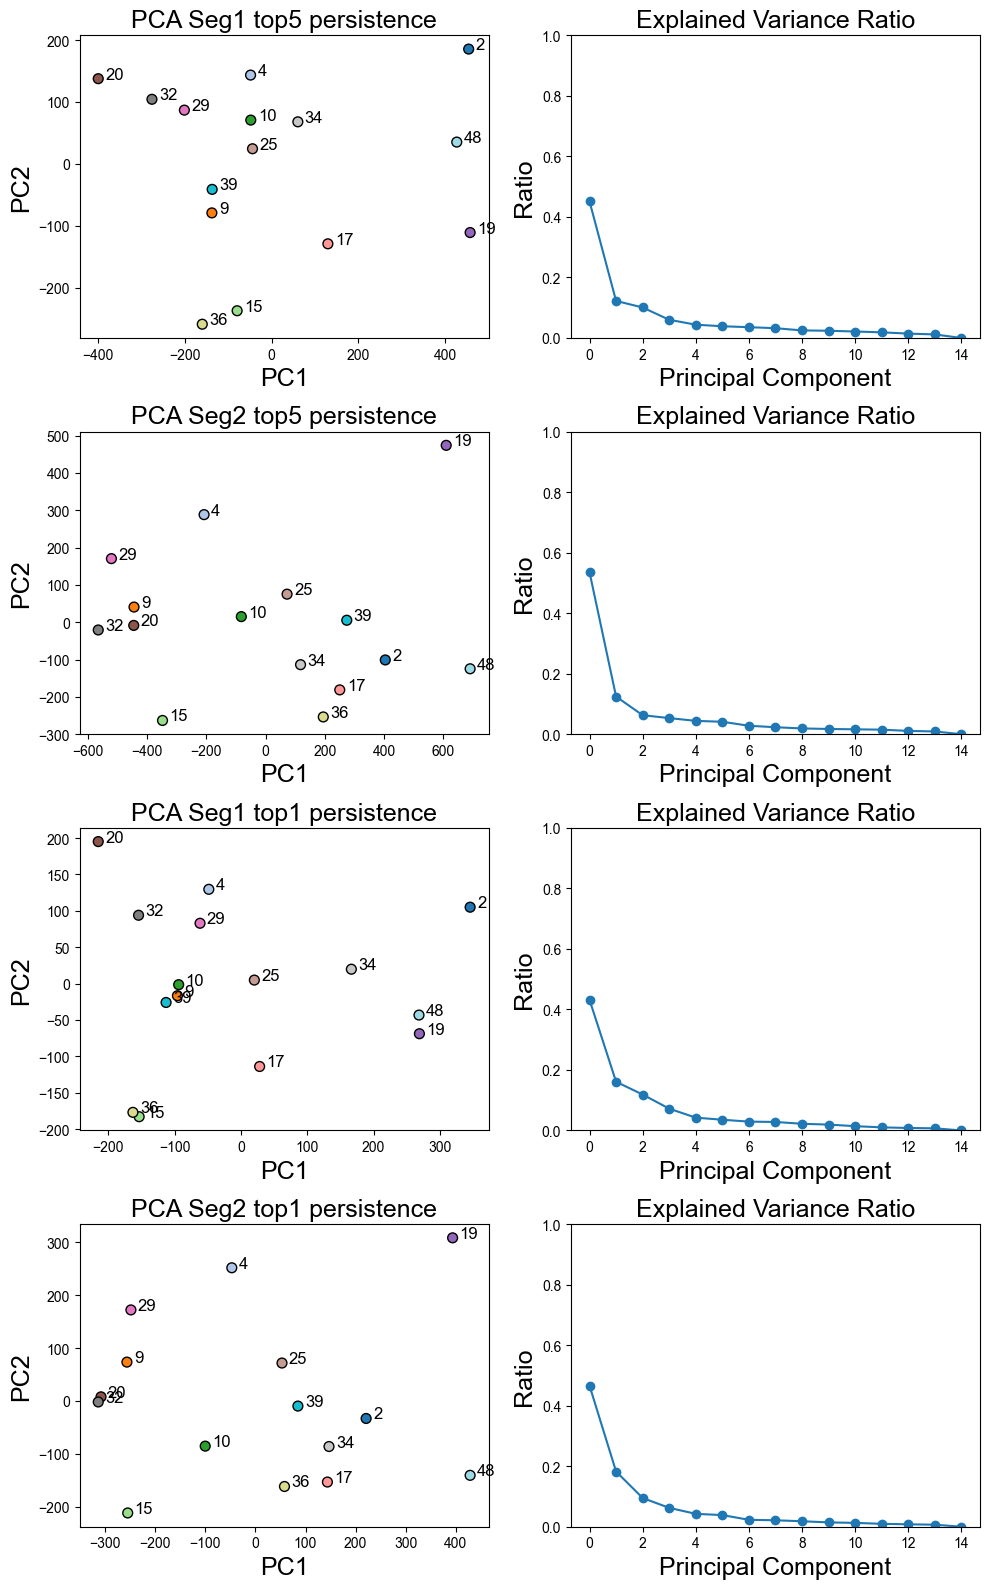

In [8]:
data_list = [project5longest_3dslicer, project5longest_medpseg, project5longest_3dslicer[:,::5], project5longest_medpseg[:,::5]]
titles = ["PCA Seg1 top5 persistence", "PCA Seg2 top5 persistence", "PCA Seg1 top1 persistence", "PCA Seg2 top1 persistence"]
id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])
plt.rcParams["font.family"] = "Arial"

n = len(data_list)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, (Results_list, title) in enumerate(zip(data_list, titles)):
    ax_scatter = axes[i, 0]
    ax_var = axes[i, 1]

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x, y = feature[:, 0], feature[:, 1]

    # --- PCA scatter ---
    sc = ax_scatter.scatter(x, y, c=num_labels, cmap='tab20', s=50, edgecolors='k')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x[j], y[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    ax_scatter.set_title(title, fontsize=18)
    ax_scatter.set_xlabel("PC1", fontsize=18)
    ax_scatter.set_ylabel("PC2", fontsize=18)

    # --- Explained variance ratio ---
    var_ratio = pca.explained_variance_ratio_

    ax_var.plot(var_ratio, marker='o')
    ax_var.set_title("Explained Variance Ratio", fontsize=18)
    ax_var.set_xlabel("Principal Component", fontsize=18)
    ax_var.set_ylabel("Ratio", fontsize=18)
    ax_var.set_ylim(0, 1)

plt.tight_layout()
plt.show()

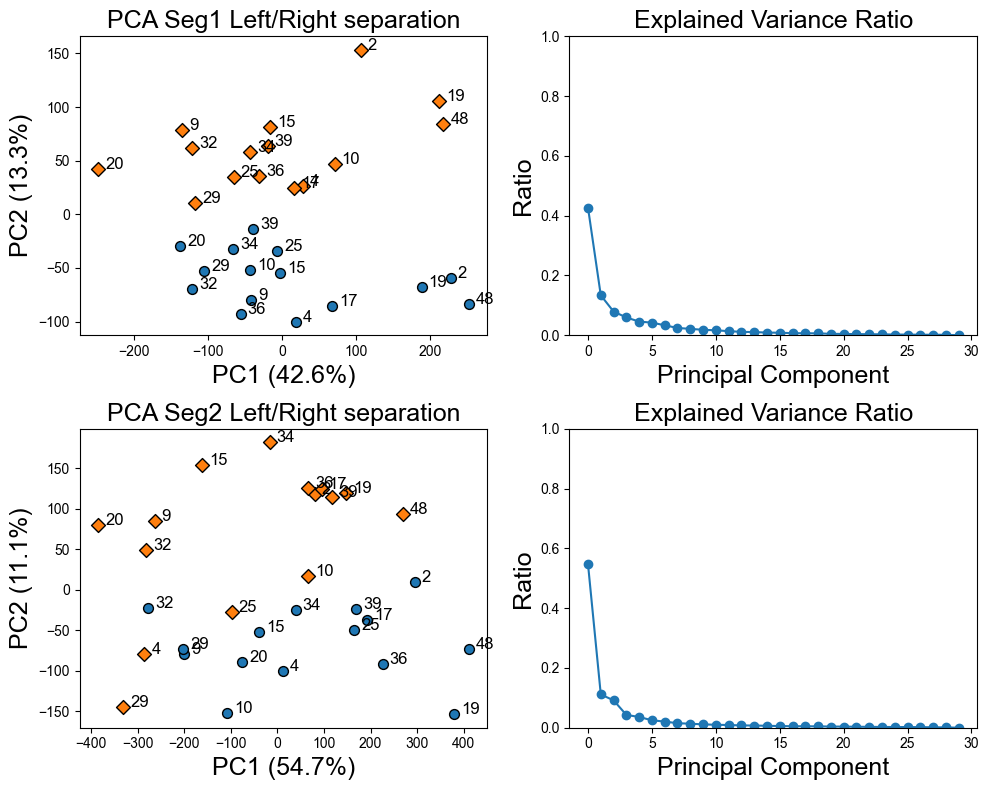

In [9]:
id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])
plt.rcParams["font.family"] = "Arial"

data_list = [projectLR_3dslicer, projectLR_medpseg]
titles = ["PCA Seg1 Left/Right separation", "PCA Seg2 Left/Right separation"]

n = len(data_list)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, (Results_list, title) in enumerate(zip(data_list, titles)):
    ax_scatter = axes[i, 0]
    ax_var = axes[i, 1]

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x1, y1 = feature[0:15, 0], feature[0:15, 1]
    ax_scatter.scatter(x1, y1, s=50, edgecolors='k')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x1[j], y1[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    x2, y2 = feature[15:30, 0], feature[15:30, 1]
    ax_scatter.scatter(x2, y2, s=50, edgecolors='k', marker='D')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x2[j], y2[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    var_ratio = pca.explained_variance_ratio_

    ax_scatter.set_title(title, fontsize=18)
    ax_scatter.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)", fontsize=18)
    ax_scatter.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)", fontsize=18)

    ax_var.plot(var_ratio, marker='o')
    ax_var.set_title("Explained Variance Ratio", fontsize=18)
    ax_var.set_xlabel("Principal Component", fontsize=18)
    ax_var.set_ylabel("Ratio", fontsize=18)
    ax_var.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### PCA analyses for Direct PHT

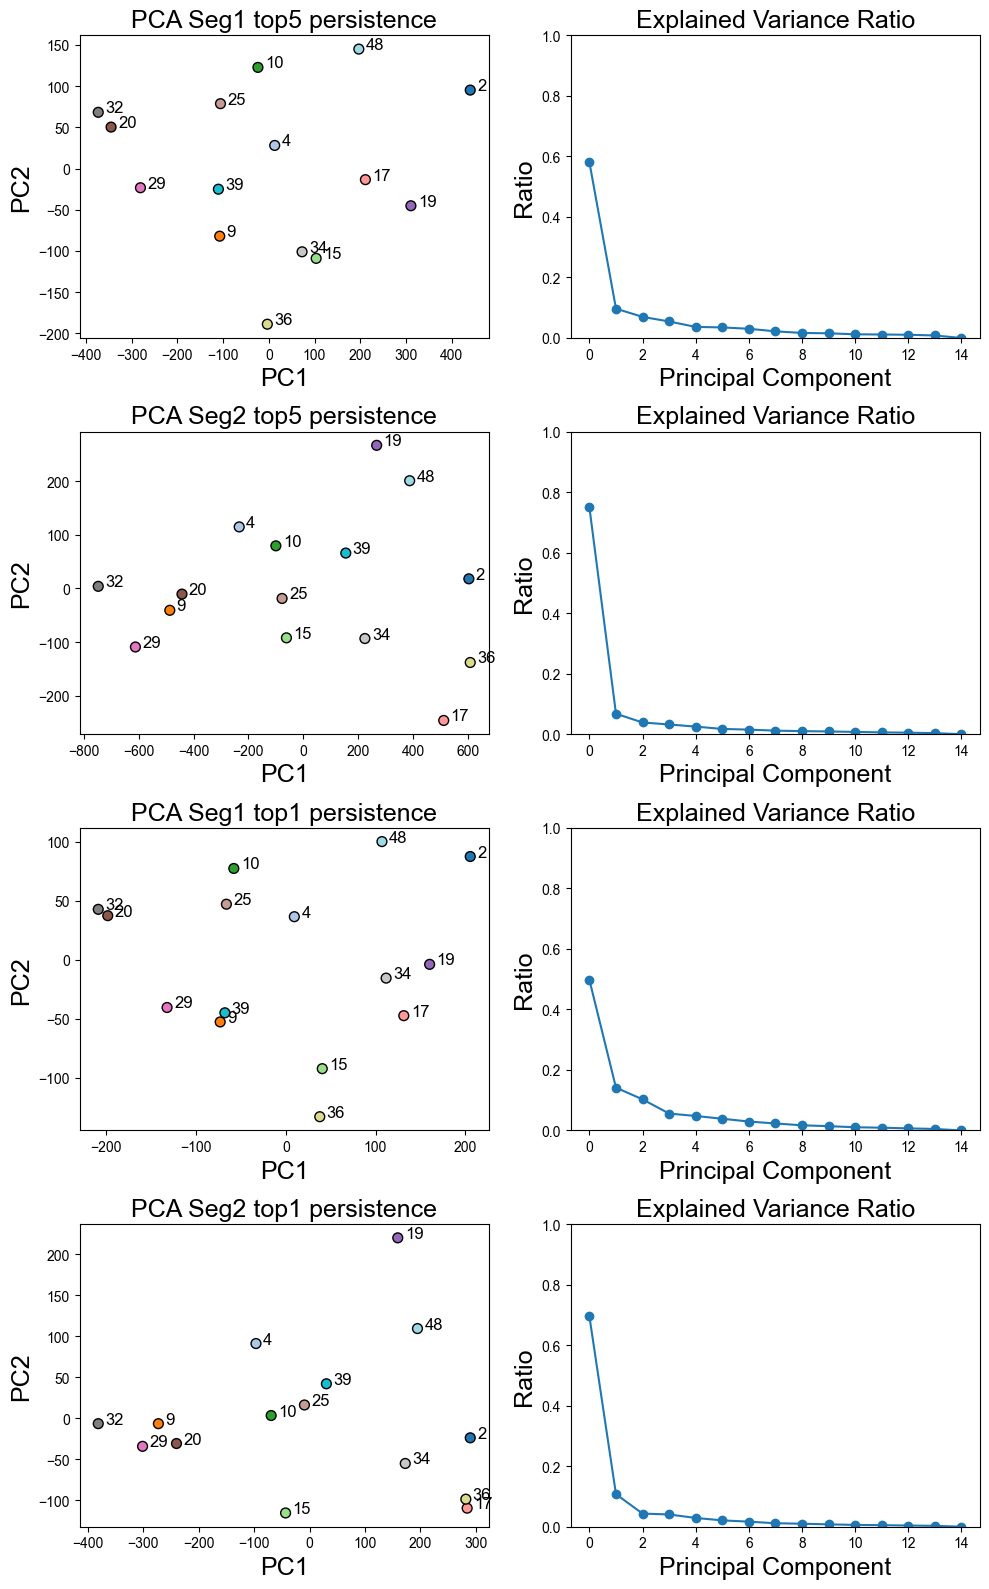

In [10]:
data_list = [direct5longest_3dslicer, direct5longest_medpseg, direct5longest_3dslicer[:,::5], direct5longest_medpseg[:,::5]]
titles = ["PCA Seg1 top5 persistence", "PCA Seg2 top5 persistence", "PCA Seg1 top1 persistence", "PCA Seg2 top1 persistence"]
id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])
plt.rcParams["font.family"] = "Arial"

n = len(data_list)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, (Results_list, title) in enumerate(zip(data_list, titles)):
    ax_scatter = axes[i, 0]
    ax_var = axes[i, 1]

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x, y = feature[:, 0], feature[:, 1]

    # --- PCA scatter ---
    sc = ax_scatter.scatter(x, y, c=num_labels, cmap='tab20', s=50, edgecolors='k')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x[j], y[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    ax_scatter.set_title(title, fontsize=18)
    ax_scatter.set_xlabel("PC1", fontsize=18)
    ax_scatter.set_ylabel("PC2", fontsize=18)

    # --- Explained variance ratio ---
    var_ratio = pca.explained_variance_ratio_

    ax_var.plot(var_ratio, marker='o')
    ax_var.set_title("Explained Variance Ratio", fontsize=18)
    ax_var.set_xlabel("Principal Component", fontsize=18)
    ax_var.set_ylabel("Ratio", fontsize=18)
    ax_var.set_ylim(0, 1)

plt.tight_layout()
plt.show()

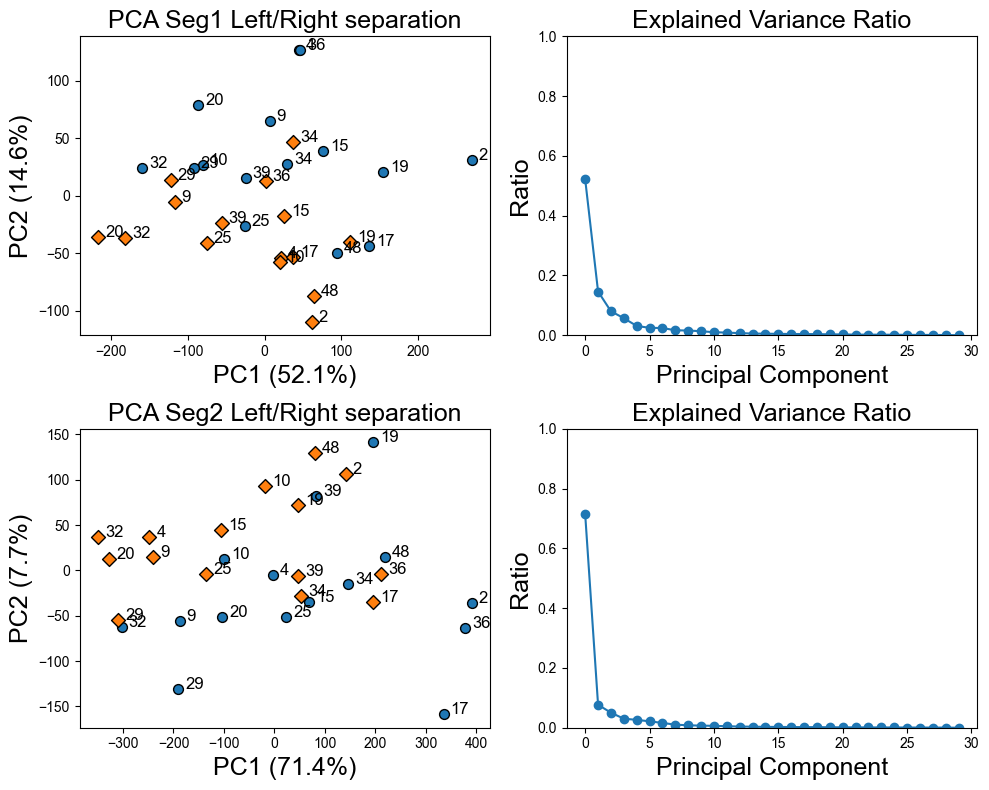

In [11]:
id_to_num = {id_: i for i, id_ in enumerate(PatientID_list)}
num_labels = np.array([id_to_num[id_] for id_ in PatientID_list])
plt.rcParams["font.family"] = "Arial"

data_list = [directLR_3dslicer, directLR_medpseg]
titles = ["PCA Seg1 Left/Right separation", "PCA Seg2 Left/Right separation"]

n = len(data_list)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, (Results_list, title) in enumerate(zip(data_list, titles)):
    ax_scatter = axes[i, 0]
    ax_var = axes[i, 1]

    pca = PCA()
    feature = pca.fit_transform(Results_list)

    x1, y1 = feature[0:15, 0], feature[0:15, 1]
    ax_scatter.scatter(x1, y1, s=50, edgecolors='k')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x1[j], y1[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    x2, y2 = feature[15:30, 0], feature[15:30, 1]
    ax_scatter.scatter(x2, y2, s=50, edgecolors='k', marker='D')

    for j, txt in enumerate(PatientID_list):
        ax_scatter.annotate(txt, (x2[j], y2[j]),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=12)

    var_ratio = pca.explained_variance_ratio_

    ax_scatter.set_title(title, fontsize=18)
    ax_scatter.set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)", fontsize=18)
    ax_scatter.set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)", fontsize=18)

    ax_var.plot(var_ratio, marker='o')
    ax_var.set_title("Explained Variance Ratio", fontsize=18)
    ax_var.set_xlabel("Principal Component", fontsize=18)
    ax_var.set_ylabel("Ratio", fontsize=18)
    ax_var.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### RV coefficient calculation

In [12]:
### Definition of RV coefficient
def rv_coefficient(X, Y):
    X = X - X.mean(axis=0)### data centering
    Y = Y - Y.mean(axis=0)
    num = np.trace(X.T @ Y @ Y.T @ X)
    den = np.sqrt(np.trace(X.T @ X @ X.T @ X) * np.trace(Y.T @ Y @ Y.T @ Y))
    return num / den

In [13]:
### Cumulative explained variance ratio of the first 9 components for Projection PHT results
pca = PCA()
feature5_3dslicer = pca.fit_transform(project5longest_3dslicer)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature5_medpseg = pca.fit_transform(project5longest_medpseg)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_3dslicer = pca.fit_transform(project5longest_3dslicer[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_medpseg = pca.fit_transform(project5longest_medpseg[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))

0.9100439289587877
0.9313054772694939
0.9407124526866182
0.948809803126214


In [14]:
print("Projection PHT")
print("top5,2seg:",rv_coefficient(feature5_3dslicer[:,0:9],feature5_medpseg[:,0:9]))
print("top1,2seg:",rv_coefficient(feature_3dslicer[:,0:9],feature_medpseg[:,0:9]))
print("top5/1,Seg1:",rv_coefficient(feature5_3dslicer[:,0:9],feature_3dslicer[:,0:9]))
print("top5/1,Seg2:",rv_coefficient(feature5_medpseg[:,0:9],feature_medpseg[:,0:9]))

Projection PHT
top5,2seg: 0.7157059331468972
top1,2seg: 0.7277391267955579
top5/1,Seg1: 0.9292290980526119
top5/1,Seg2: 0.955831715670709


In [15]:
### Cumulative explained variance ratio of the first 9 components for Direct PHT results
pca = PCA()
feature5_3dslicer = pca.fit_transform(direct5longest_3dslicer)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature5_medpseg = pca.fit_transform(direct5longest_medpseg)
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_3dslicer = pca.fit_transform(direct5longest_3dslicer[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))
pca = PCA()
feature_medpseg = pca.fit_transform(direct5longest_medpseg[:,::5])
print(np.sum(np.array(pca.explained_variance_ratio_[0:9])))

0.9421315520133209
0.9684021019989195
0.9539543680511395
0.9742420522424046


In [16]:
print("Direct PHT")
print("top5,2seg:",rv_coefficient(feature5_3dslicer[:,0:9],feature5_medpseg[:,0:9]))
print("top1,2seg:",rv_coefficient(feature_3dslicer[:,0:9],feature_medpseg[:,0:9]))
print("top5/1,Seg1:",rv_coefficient(feature5_3dslicer[:,0:9],feature_3dslicer[:,0:9]))
print("top5/1,Seg2:",rv_coefficient(feature5_medpseg[:,0:9],feature_medpseg[:,0:9]))

Direct PHT
top5,2seg: 0.6916974346853357
top1,2seg: 0.7672381503482866
top5/1,Seg1: 0.9471380159744914
top5/1,Seg2: 0.9824385713763958


### R/L Classification with test data

In [18]:
### Loading test dataset
project_test_3dslicer=np.load('../feature_vectors/project_test_3dslicer.npy')
project_test_medpseg=np.load('../feature_vectors/project_test_medpseg.npy')
direct_test_3dslicer=np.load('../feature_vectors/direct_test_3dslicer.npy')
direct_test_medpseg=np.load('../feature_vectors/direct_test_medpseg.npy')

In [19]:
### Class information for train dataset (half left. half right)
Class=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
len(Class),len(np.where(Class==0)[0])

(30, 15)

In [20]:
### Seg1 with Projection PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_3dslicer, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_3dslicer)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_3dslicer)
    Y_proba=lr.predict_proba(project_test_3dslicer)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.99065704e-01 9.34295830e-04]
 [6.21255753e-01 3.78744247e-01]
 [9.99695115e-01 3.04884734e-04]
 [9.91155555e-01 8.84444537e-03]
 [2.44930784e-05 9.99975507e-01]
 [2.44538675e-01 7.55461325e-01]
 [7.95231532e-04 9.99204768e-01]
 [8.84036843e-05 9.99911596e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.99784537e-01 2.15463373e-04]
 [6.07343819e-01 3.92656181e-01]
 [9.99946744e-01 5.32559587e-05]
 [9.96628824e-01 3.37117583e-03]
 [3.22162759e-06 9.99996778e-01]
 [1.92410701e-01 8.07589299e-01]
 [1.88423168e-04 9.99811577e-01]
 [1.45734737e-05 9.99985427e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

In [21]:
### Seg1 with Direct PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(directLR_3dslicer, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(directLR_3dslicer)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(direct_test_3dslicer)
    Y_proba=lr.predict_proba(direct_test_3dslicer)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[9.98262599e-01 1.73740065e-03]
 [2.93251978e-02 9.70674802e-01]
 [9.99759674e-01 2.40325981e-04]
 [9.97164204e-01 2.83579551e-03]
 [1.00077789e-05 9.99989992e-01]
 [1.29775265e-02 9.87022473e-01]
 [3.00530120e-03 9.96994699e-01]
 [1.99817156e-02 9.80018284e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[9.99644736e-01 3.55263575e-04]
 [1.34606720e-02 9.86539328e-01]
 [9.99971778e-01 2.82221263e-05]
 [9.99355513e-01 6.44486770e-04]
 [5.14089131e-07 9.99999486e-01]
 [4.45113476e-03 9.95548865e-01]
 [8.32935876e-04 9.99167064e-01]
 [8.65223781e-03 9.91347762e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1

In [22]:
### Seg2 with Projection PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_medpseg, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_medpseg)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_medpseg)
    Y_proba=lr.predict_proba(project_test_medpseg)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.97376086e-01 2.62391399e-03]
 [9.98457196e-01 1.54280374e-03]
 [9.99846443e-01 1.53556603e-04]
 [9.95237703e-01 4.76229692e-03]
 [2.03141462e-04 9.99796859e-01]
 [6.32293442e-05 9.99936771e-01]
 [1.10711870e-04 9.99889288e-01]
 [8.75807939e-04 9.99124192e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.99269136e-01 7.30864051e-04]
 [9.99570052e-01 4.29948463e-04]
 [9.99976273e-01 2.37265551e-05]
 [9.98348011e-01 1.65198877e-03]
 [3.34355094e-05 9.99966564e-01]
 [7.32483273e-06 9.99992675e-01]
 [1.67943386e-05 9.99983206e-01]
 [1.94592262e-04 9.99805408e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

In [23]:
### Seg2 with Direct PHT
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(directLR_medpseg, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(directLR_medpseg)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(direct_test_medpseg)
    Y_proba=lr.predict_proba(direct_test_medpseg)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[8.65740857e-01 1.34259143e-01]
 [9.98223241e-01 1.77675856e-03]
 [9.99844396e-01 1.55603885e-04]
 [9.99998732e-01 1.26829853e-06]
 [2.31158823e-05 9.99976884e-01]
 [3.07310569e-03 9.96926894e-01]
 [2.34214456e-04 9.99765786e-01]
 [3.98096067e-01 6.01903933e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1]
prediction probability:
[[9.35896851e-01 6.41031491e-02]
 [9.99460966e-01 5.39034012e-04]
 [9.99980543e-01 1.94573992e-05]
 [9.99999942e-01 5.83354335e-08]
 [2.84163103e-06 9.99997158e-01]
 [8.42666168e-04 9.99157334e-01]
 [4.32413232e-05 9.99956759e-01]
 [4.17473440e-01 5.82526560e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 0 0 1 1 1 1

In [24]:
### generalize across different segmentation methods
print("Projection PHT Seg1 > Seg2")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_3dslicer, Class)
Y_pred = lr.predict(project_test_medpseg)
print("test data result")
print('prediction:',Y_pred)

print("Projection PHT Seg2 > Seg1")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_medpseg, Class)
Y_pred = lr.predict(project_test_3dslicer)
print("test data result")
print('prediction:',Y_pred)

print("Direct PHT Seg1 > Seg2")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_3dslicer, Class)
Y_pred = lr.predict(direct_test_medpseg)
print("test data result")
print('prediction:',Y_pred)

print("Direct PHT Seg2 > Seg1")
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_medpseg, Class)
Y_pred = lr.predict(direct_test_3dslicer)
print("test data result")
print('prediction:',Y_pred)

Projection PHT Seg1 > Seg2
test data result
prediction: [0 0 0 0 1 1 1 1]
Projection PHT Seg2 > Seg1
test data result
prediction: [0 1 0 0 1 1 1 1]
Direct PHT Seg1 > Seg2
test data result
prediction: [0 0 0 0 1 1 1 0]
Direct PHT Seg2 > Seg1
test data result
prediction: [0 1 0 0 1 1 1 1]


### Contribution analysis

In [25]:
### PC2 for Projection PHT with Seg1 separated L/R clearly.
pca = PCA()
feature = pca.fit_transform(projectLR_3dslicer)

In [26]:
### PC1 values are R negative, L positive
feature[:,1]

array([ -59.14880001, -100.03007867,  -79.40776231,  -51.45177473,
        -54.73381952,  -85.68294558,  -67.80106072,  -29.9523838 ,
        -34.16072808,  -52.54060655,  -69.49520437,  -32.31048704,
        -93.1515956 ,  -13.30052119,  -83.85138237,  153.32731095,
         26.17939069,   78.31419976,   46.94005307,   81.28117804,
         24.46925521,  105.91663165,   42.23117193,   34.6712663 ,
         10.99133334,   61.9196071 ,   57.84599586,   35.59122535,
         63.3834225 ,   83.95710881])

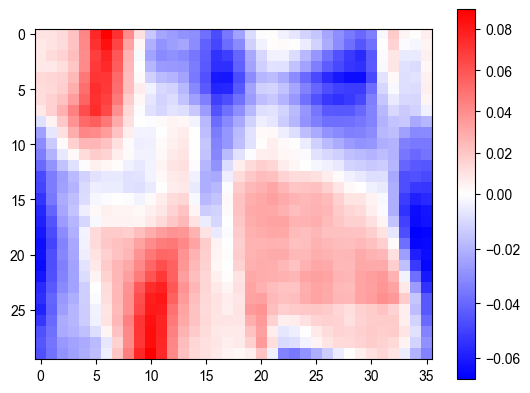

In [27]:
### Positive values contribute to left-likeness, negative values contribute to right-likeness
from matplotlib.colors import TwoSlopeNorm
grid1 = pca.components_[1].reshape((30, 36)) 
vmin = np.min(grid1)
vmax = np.max(grid1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.imshow(grid1, cmap='bwr', norm=norm)
plt.colorbar()
plt.show()

In [24]:
### Although it is difficult to interpret everything, we can see, for example, that the very red parts in the left hand side corresponds to the longer main branch of left airways seen from front and back.

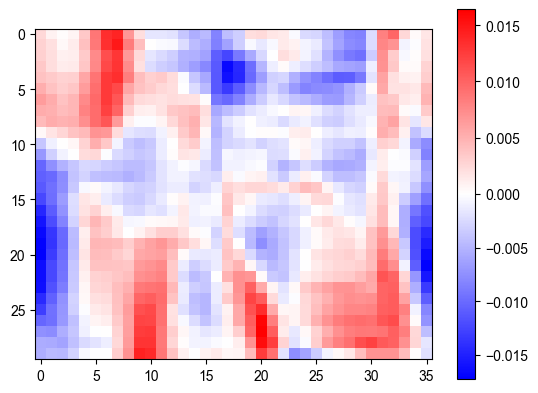

In [28]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_3dslicer, Class)
from matplotlib.colors import TwoSlopeNorm
plt.rcParams["font.family"] = "Arial"
grid2 = lr.coef_.reshape((30, 36)) 
# 値の範囲
vmin = np.min(grid2)
vmax = np.max(grid2)

# 0を中央（白）に固定
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.imshow(grid2, cmap='bwr', norm=norm)
plt.colorbar()
plt.show()

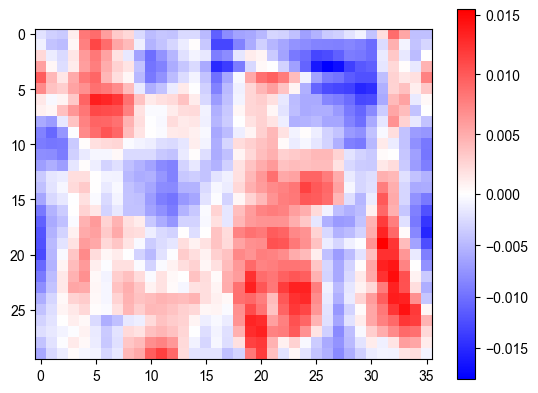

In [29]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(projectLR_medpseg, Class)
from matplotlib.colors import TwoSlopeNorm
plt.rcParams["font.family"] = "Arial"
grid3 = lr.coef_.reshape((30, 36)) 
# 値の範囲
vmin = np.min(grid3)
vmax = np.max(grid3)

# 0を中央（白）に固定
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.imshow(grid3, cmap='bwr', norm=norm)
plt.colorbar()
plt.show()

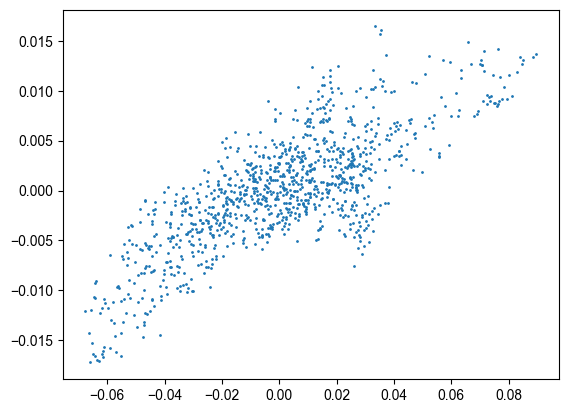

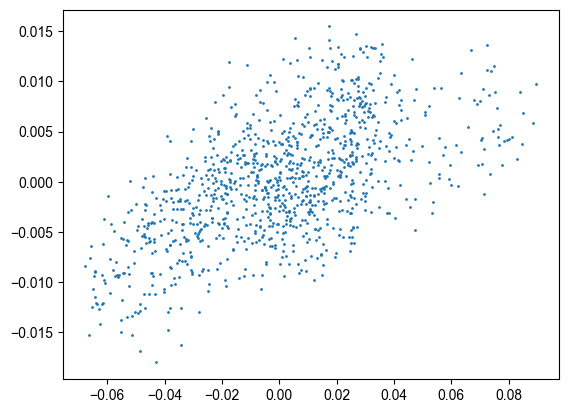

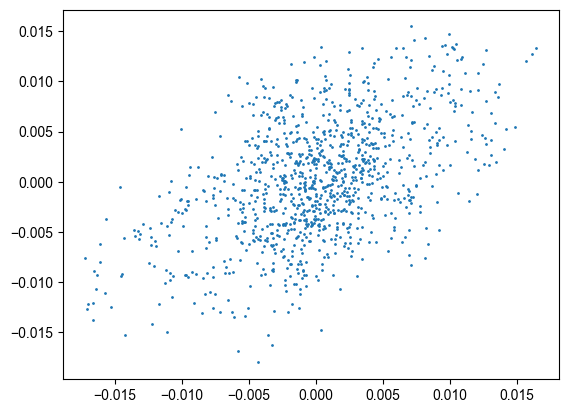

In [30]:
### pixelwise similarity
plt.scatter(grid1.flatten(),grid2.flatten(),s=1)
plt.show()
plt.scatter(grid1.flatten(),grid3.flatten(),s=1)
plt.show()
plt.scatter(grid2.flatten(),grid3.flatten(),s=1)
plt.show()

### Subset model

Feature vectors are generated by the following loops
```
for j in range (0,rotations):
        for k in range (0,directions):
```
To extract upward directions, we use the following.


In [78]:
## upward
### Seg1
col_idx = np.arange(projectLR_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
projectLR_3dslicer_upward=projectLR_3dslicer[:,mask]
print(projectLR_3dslicer_upward.shape)
col_idx = np.arange(project_test_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
project_test_3dslicer_upward=project_test_3dslicer[:,mask]
print(project_test_3dslicer_upward.shape)
### Seg2
col_idx = np.arange(projectLR_medpseg.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
projectLR_medpseg_upward=projectLR_medpseg[:,mask]
print(projectLR_medpseg_upward.shape)
col_idx = np.arange(project_test_medpseg.shape[1])
mask = np.isin(col_idx % 36, [7, 8, 9])
project_test_medpseg_upward=project_test_medpseg[:,mask]
print(project_test_medpseg_upward.shape)

(30, 90)
(8, 90)
(30, 90)
(8, 90)


In [79]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_3dslicer_upward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_3dslicer_upward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_3dslicer_upward)
    Y_proba=lr.predict_proba(project_test_3dslicer_upward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[9.97375613e-01 2.62438703e-03]
 [3.81058642e-02 9.61894136e-01]
 [7.40274317e-01 2.59725683e-01]
 [9.89654212e-01 1.03457883e-02]
 [5.41893437e-05 9.99945811e-01]
 [5.11569449e-02 9.48843055e-01]
 [1.41890190e-03 9.98581098e-01]
 [5.34062719e-04 9.99465937e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[9.99696300e-01 3.03699756e-04]
 [8.19208883e-03 9.91807911e-01]
 [9.32182457e-01 6.78175433e-02]
 [9.99291236e-01 7.08763927e-04]
 [1.32174765e-06 9.99998678e-01]
 [1.45347207e-02 9.85465279e-01]
 [1.69036800e-04 9.99830963e-01]
 [1.75405954e-05 9.99982459e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1

In [80]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_medpseg_upward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_medpseg_upward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_medpseg_upward)
    Y_proba=lr.predict_proba(project_test_medpseg_upward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[6.40209106e-01 3.59790894e-01]
 [2.11696123e-01 7.88303877e-01]
 [6.38411135e-01 3.61588865e-01]
 [7.12154979e-01 2.87845021e-01]
 [7.15600756e-04 9.99284399e-01]
 [4.41170395e-04 9.99558830e-01]
 [3.67342289e-01 6.32657711e-01]
 [9.06549428e-03 9.90934506e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1]
prediction probability:
[[5.80658052e-01 4.19341948e-01]
 [1.36161477e-01 8.63838523e-01]
 [7.26057737e-01 2.73942263e-01]
 [7.39208099e-01 2.60791901e-01]
 [4.93700699e-05 9.99950630e-01]
 [2.41844176e-05 9.99975816e-01]
 [3.20838891e-01 6.79161109e-01]
 [9.83248338e-04 9.99016752e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 1 0 0 1 1 1 1

In [81]:
## downward
### Seg1
col_idx = np.arange(projectLR_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
projectLR_3dslicer_downward=projectLR_3dslicer[:,mask]
print(projectLR_3dslicer_downward.shape)
col_idx = np.arange(project_test_3dslicer.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
project_test_3dslicer_downward=project_test_3dslicer[:,mask]
print(project_test_3dslicer_downward.shape)
### Seg2
col_idx = np.arange(projectLR_medpseg.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
projectLR_medpseg_downward=projectLR_medpseg[:,mask]
print(projectLR_medpseg_downward.shape)
col_idx = np.arange(project_test_medpseg.shape[1])
mask = np.isin(col_idx % 36, [25, 26, 27])
project_test_medpseg_downward=project_test_medpseg[:,mask]
print(project_test_medpseg_downward.shape)

(30, 90)
(8, 90)
(30, 90)
(8, 90)


In [82]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_3dslicer_downward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_3dslicer_downward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_3dslicer_downward)
    Y_proba=lr.predict_proba(project_test_3dslicer_downward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 0 1 0]
prediction probability:
[[1.35699715e-01 8.64300285e-01]
 [9.37616835e-01 6.23831649e-02]
 [1.44245518e-01 8.55754482e-01]
 [1.54401113e-01 8.45598887e-01]
 [6.36773065e-04 9.99363227e-01]
 [8.46004798e-01 1.53995202e-01]
 [7.28712318e-02 9.27128768e-01]
 [8.39870735e-01 1.60129265e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 0 1 0]
prediction probability:
[[1.08853817e-01 8.91146183e-01]
 [9.87545821e-01 1.24541795e-02]
 [7.91657808e-02 9.20834219e-01]
 [6.38944364e-02 9.36105564e-01]
 [6.26236997e-06 9.99993738e-01]
 [9.45924669e-01 5.40753312e-02]
 [1.16456060e-02 9.88354394e-01]
 [9.51277661e-01 4.87223395e-02]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 0 1 0

In [83]:
for regval in [0.1,0.5,1,3,5]:
    print("========")
    print("C=",regval)
    lr = LogisticRegression(C=regval,penalty='l2',random_state=0, solver='liblinear') 
    lr.fit(projectLR_medpseg_downward, Class)
    #print("coefficient = ", lr.coef_)
    #print("intercept = ", lr.intercept_)
    Y_pred = lr.predict(projectLR_medpseg_downward)
    print("train data classification")
    print(Y_pred)
    Y_pred = lr.predict(project_test_medpseg_downward)
    Y_proba=lr.predict_proba(project_test_medpseg_downward)
    print("test data result")
    print('prediction:',Y_pred)
    print('prediction probability:')
    print(Y_proba)

C= 0.1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 1 1 1]
prediction probability:
[[4.62328174e-01 5.37671826e-01]
 [9.54919748e-01 4.50802516e-02]
 [5.00824671e-03 9.94991753e-01]
 [3.45832424e-01 6.54167576e-01]
 [2.32426539e-03 9.97675735e-01]
 [2.18168520e-04 9.99781831e-01]
 [2.69650849e-04 9.99730349e-01]
 [1.71851228e-03 9.98281488e-01]]
C= 0.5
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [1 0 1 1 1 1 1 1]
prediction probability:
[[4.95753200e-01 5.04246800e-01]
 [9.72249577e-01 2.77504234e-02]
 [4.51572160e-04 9.99548428e-01]
 [3.26518587e-01 6.73481413e-01]
 [2.30481779e-04 9.99769518e-01]
 [8.19011879e-06 9.99991810e-01]
 [1.89476797e-05 9.99981052e-01]
 [2.17097447e-04 9.99782903e-01]]
C= 1
train data classification
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
test data result
prediction: [0 0 1 1 1 1 1 1

In [31]:
def octahedron_directions(f=9):
    # Integer lattice points on the L1 “sphere”: |i|+|j|+|k| = f
    pts = []
    for i in range(-f, f+1):
        for j in range(-f, f+1):
            k_abs = f - abs(i) - abs(j)
            if k_abs < 0:
                continue
            if k_abs == 0:
                pts.append((i, j, 0))
            else:
                pts.append((i, j,  k_abs))
                pts.append((i, j, -k_abs))

    # Unique & sorted for reproducibility
    pts = sorted(set(pts))

    # Map to the octahedron surface (divide by f), then project to unit sphere
    V = np.array(pts, dtype=float) / f
    norms = np.linalg.norm(V, axis=1, keepdims=True)
    dirs = V / norms  # 326 unit vectors

    return dirs  # shape: (326, 3)

In [37]:
from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
def plot_direction_heat_mesh(dirs, values, title=None, cmap_name="bwr", orientation=True,save_path=None):
    values = np.asarray(values).ravel()

    triangles = ConvexHull(dirs).simplices
    face_values = values[triangles].mean(axis=1)

    if values.min() < 0 < values.max():
        norm = TwoSlopeNorm(vmin=values.min(), vcenter=0, vmax=values.max())
    else:
        norm = Normalize(vmin=values.min(), vmax=values.max())

    cmap = plt.get_cmap(cmap_name)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    mesh = Poly3DCollection(
        dirs[triangles],
        facecolors=cmap(norm(face_values)),
        edgecolors=(0, 0, 0, 0.08),
        linewidths=0.15,
    )
    ax.add_collection3d(mesh)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1,1,1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if orientation:
        ax.view_init(elev=25, azim=45)
    else:
        ax.view_init(elev=25, azim=225)
    
    if title:
        ax.set_title(title)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(values)
    plt.colorbar(sm, ax=ax, shrink=0.7)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [33]:
pca = PCA()
feature = pca.fit_transform(directLR_3dslicer)
feature[:,1]

array([  30.78160526,  126.81560874,   64.97576209,   26.92452669,
         38.77775471,  -43.52362894,   20.60465121,   79.0596641 ,
        -25.87007841,   24.24839373,   23.87809823,   27.54140775,
        126.96339326,   15.61407302,  -49.92240797, -109.39250006,
        -54.38162705,   -5.68666637,  -57.45271387,  -17.1753356 ,
        -52.78309307,  -39.69189158,  -35.98971162,  -41.08972704,
         14.11617719,  -36.83006128,   47.22660961,   13.16915733,
        -23.59201683,  -87.31542323])

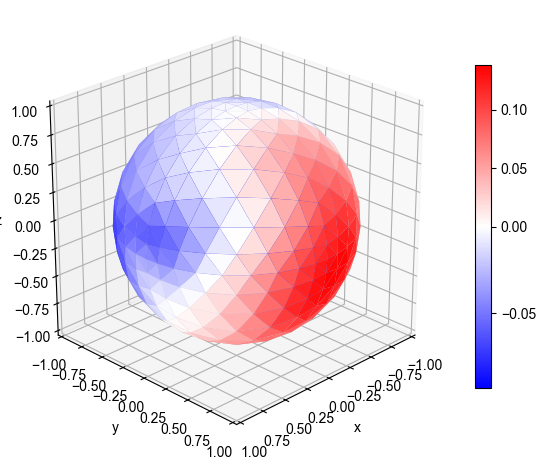

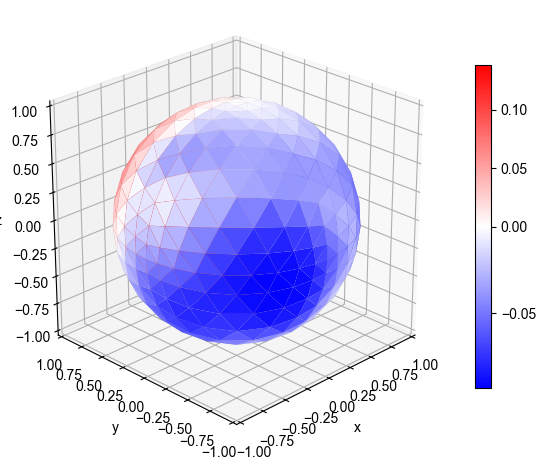

In [38]:
dirs = octahedron_directions()
loadings = pca.components_[1]

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=True
)

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=False
)

In [39]:
### Class information for train dataset (half left. half right)
Class=np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1])
len(Class),len(np.where(Class==0)[0])

(30, 15)

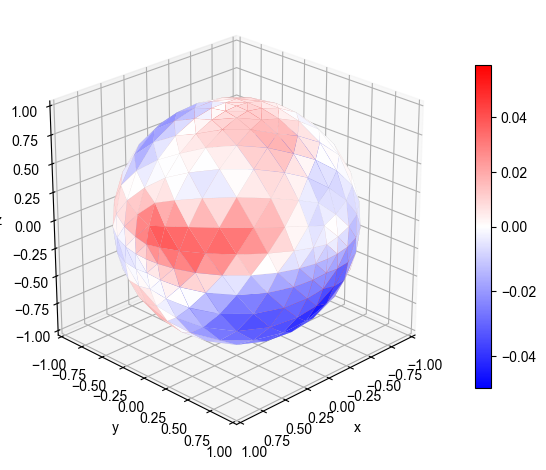

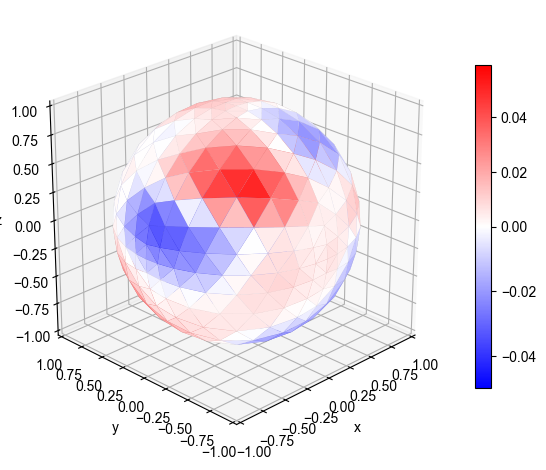

In [40]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_3dslicer, Class)
dirs = octahedron_directions()
loadings = lr.coef_.ravel()

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=True
)

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=False
)

In [ ]:
lr = LogisticRegression(C=1,penalty='l2',random_state=0, solver='liblinear') 
lr.fit(directLR_medpseg, Class)
dirs = octahedron_directions()
loadings = lr.coef_.ravel()

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=True
)

plot_direction_heat_mesh(
    dirs,
    loadings,
    orientation=False
)